In [ ]:
import pandas as pd

df = pd.read_csv("Heart_Disease.csv")
df.head()
df.info()

/tmp/ipykernel_287/1628958433.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Heart_Disease.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5770240 entries, 0 to 5770239
Data columns (total 21 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Year                        object 
 1   LocationAbbr                object 
 2   LocationDesc                object 
 3   GeographicLevel             object 
 4   DataSource                  object 
 5   Class                       object 
 6   Topic                       object 
 7   Data_Value                  float64
 8   Data_Value_Unit             object 
 9   Data_Value_Type             object 
 10  Data_Value_Footnote_Symbol  object 
 11  Data_Value_Footnote         object 
 12  Confidence_limit_Low        float64
 13  Confidence_limit_High       float64
 14  StratificationCategory1     object 
 15  Stratification1             object 
 16  StratificationCategory2     object 
 17  Stratification2             object 
 18  StratificationCategory3     object 
 19  Stratification3      

##Understanding the Dataset (EDA)

In [ ]:
# checking for temporal columns such as year, date, etc..
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5770240 entries, 0 to 5770239
Data columns (total 21 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Year                        object 
 1   LocationAbbr                object 
 2   LocationDesc                object 
 3   GeographicLevel             object 
 4   DataSource                  object 
 5   Class                       object 
 6   Topic                       object 
 7   Data_Value                  float64
 8   Data_Value_Unit             object 
 9   Data_Value_Type             object 
 10  Data_Value_Footnote_Symbol  object 
 11  Data_Value_Footnote         object 
 12  Confidence_limit_Low        float64
 13  Confidence_limit_High       float64
 14  StratificationCategory1     object 
 15  Stratification1             object 
 16  StratificationCategory2     object 
 17  Stratification2             object 
 18  StratificationCategory3     object 
 19  Stratification3      

,Data_Value,Confidence_limit_Low,Confidence_limit_High,LocationID
count,3.404765e+06,3.404765e+06,3.404765e+06,5.770240e+06
mean,4.488776e+02,3.913012e+02,5.161698e+02,3.043810e+04
std,6.257945e+02,5.640739e+02,6.960195e+02,1.512336e+04
min,-9.810000e+01,-9.940000e+01,-9.200000e+01,1.001000e+03
25%,2.490000e+01,1.790000e+01,3.720000e+01,1.900250e+04
50%,1.438000e+02,1.200000e+02,1.735000e+02,2.918200e+04
75%,5.936000e+02,5.007000e+02,7.055000e+02,4.508350e+04
max,4.188400e+03,3.807500e+03,5.035200e+03,5.604500e+04


In [ ]:
# Converting year from string to numeric
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year', 'Data_Value'])
df['Year'] = df['Year'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3108720 entries, 53 to 5268498
Data columns (total 21 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Year                        int64  
 1   LocationAbbr                object 
 2   LocationDesc                object 
 3   GeographicLevel             object 
 4   DataSource                  object 
 5   Class                       object 
 6   Topic                       object 
 7   Data_Value                  float64
 8   Data_Value_Unit             object 
 9   Data_Value_Type             object 
 10  Data_Value_Footnote_Symbol  object 
 11  Data_Value_Footnote         object 
 12  Confidence_limit_Low        float64
 13  Confidence_limit_High       float64
 14  StratificationCategory1     object 
 15  Stratification1             object 
 16  StratificationCategory2     object 
 17  Stratification2             object 
 18  StratificationCategory3     object 
 19  Stratification3          

In [ ]:
print(df['Stratification1'].unique())

['Ages 35-64 years' 'Ages 65 years and older']


In [ ]:
# this removes gender/age splits -> Cleaner analysis.
df = df[df['Stratification1'] == 'Overall']

##Starting again -> Attempt 2
1.   Loading data set
2.   Fix Core Columns
3.   Create Time Series
4.   Plot the Time Series
5.   Decomposition
6.   Stationarity Test
7.   ACF & PACF Plots
8.   Train-Test Split
9.   ARIMA Model
10.  
11.  
12.  
13.  





In [ ]:
df = pd.read_csv("Heart_Disease.csv", low_memory=False)

In [ ]:
# Step 2: Fix Core Columns
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Data_Value'] = pd.to_numeric(df['Data_Value'], errors='coerce')

df = df.dropna(subset=['Year', 'Data_Value'])
df['Year'] = df['Year'].astype(int)

In [ ]:
# Step 3: Create Time Series (Baseline)
ts = df.groupby('Year')['Data_Value'].mean()
ts = ts.sort_index()

print(ts)

Year
1999    654.378824
2000    637.858300
2001    617.989555
2002    608.264816
2003    589.616238
2004    550.562482
2005    539.879701
2006    508.711408
2007    487.687681
2008    478.739133
2009    454.980428
2010    447.857377
2011    434.128569
2012    425.389171
2013    424.029768
2014    418.242061
2015    422.396760
2016    414.954829
2017    415.286313
2018    410.242330
2019    406.414249
Name: Data_Value, dtype: float64


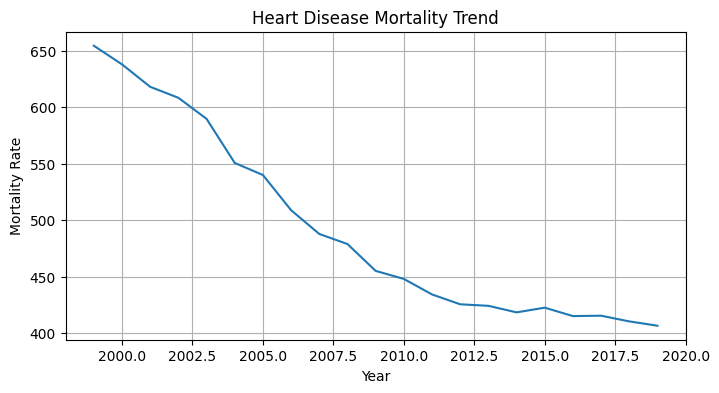

In [ ]:
# Step 4: Plot the Time Series
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(ts)
plt.title("Heart Disease Mortality Trend")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.grid()
plt.show()

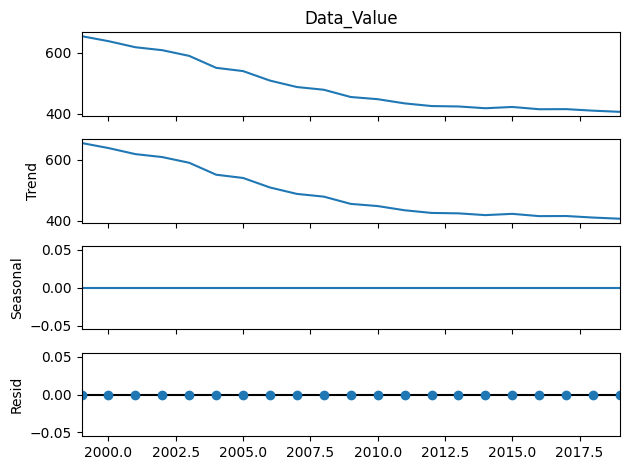

In [ ]:
# Step 5: Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(ts, model='additive', period=1)
fig = result.plot()
plt.show()

In [ ]:
# Step 6: Stationarity Test -> Whhy ? ARIMA models works properly if the series
#is stationary
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -3.234084940691736
p-value: 0.01809456284684964


**Interpretation**

1. p = 0.018 < 0.05 => ***stationary***

2. One may say that as the TS has decreasing trend so TS must not be stationary, but ADF saya ***"The Trend is not strong enough to violate stationarity statistically"***.

Finally, “The Augmented Dickey-Fuller (ADF) test was performed to check for stationarity. The obtained p-value (0.018) is less than the significance level of 0.05, indicating that the null hypothesis of non-stationarity can be rejected. Hence, the time series is considered stationary.”





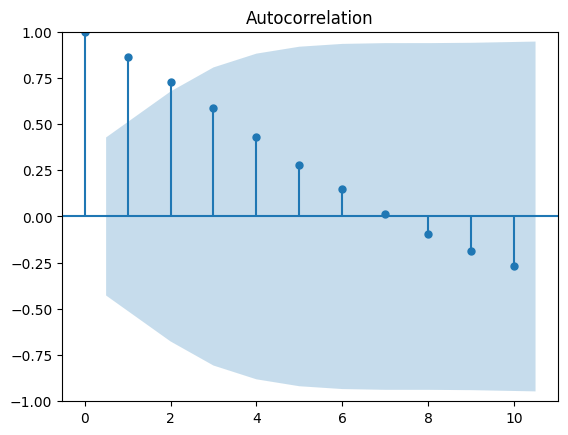

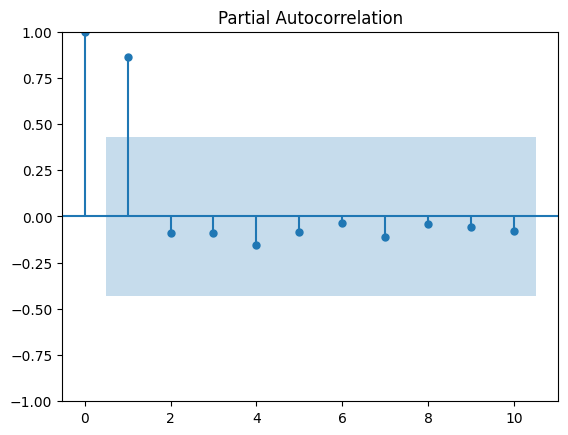

In [ ]:
# Step 7: ACF & PACF -> Why ? Used to choose ARIMA parameters (p,q)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig_acf = plot_acf(ts)
fig_pacf = plot_pacf(ts)
plt.show()

**Interpretation**

1. ACF plot:
   

*   Slowly decreasing
*   No Sharp cutoff

These both observations suggests AR component is present.

2. PACF plot:


*   Big spike
*   After that -> mostly insignificant

This means p = 1.



Finally, The best starting model is

```
ARIMA(1,0,0)
```
where , p = 1 (from PACF)
        d = 0 (stationary)
        q = 0 (ACF doesn't cut sharply)


In [ ]:
ts.index = pd.to_datetime(ts.index, format='%Y')
ts = ts.asfreq('YS')   # Year Start frequency

In [ ]:
# Step 8: Train-Test Split -> Why ? need fro validation
# train = ts[:2015]
# test = ts[2016:]
# Slicing like above is not working properly this creates train -> okay but test
#empty you can also try doing it uncomment and comment carefully and try printi-
#-ng you will get 21,0

train = ts.iloc[:17]
test = ts.iloc[17:]
print(len(train), len(test))

17 4


What is iloc and loc ? what do they do ?
loc -> label-based indexing -> Uses actual index values
iloc -> position-based indexing -> Use row numbers (0,1,2..)

As you can see after using iloc train and test split is awesome

In [ ]:
# Step 9: Build ARIMA Model
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,0,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

print(forecast)

2016-01-01    423.891689
2017-01-01    425.366884
2018-01-01    426.822607
2019-01-01    428.259114
Freq: YS-JAN, Name: predicted_mean, dtype: float64


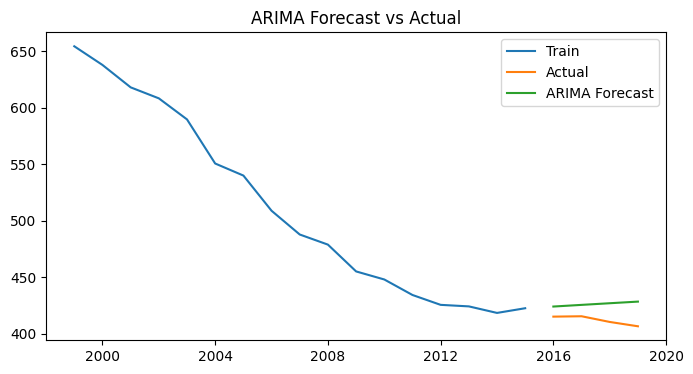

In [ ]:
# Step 10: Plot ARIMA Forecast vs Actual
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='ARIMA Forecast')

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(test, forecast)
print("ARIMA MSE:", mse)

ARIMA MSE: 233.3972669564813


In [ ]:
# Step 11: Run Linear Regression model and compare it with ARIMA
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.arange(len(train)).reshape(-1,1)
y = train.values

lr = LinearRegression().fit(X, y)

X_test = np.arange(len(train), len(train)+len(test)).reshape(-1,1)
pred_lr = lr.predict(X_test)

# Comparing ARIMA and Linear regression models
print("ARIMA:", mean_squared_error(test, forecast))
print("Linear Regression:", mean_squared_error(test, pred_lr))

ARIMA: 233.3972669564813
Linear Regression: 5088.622030586984


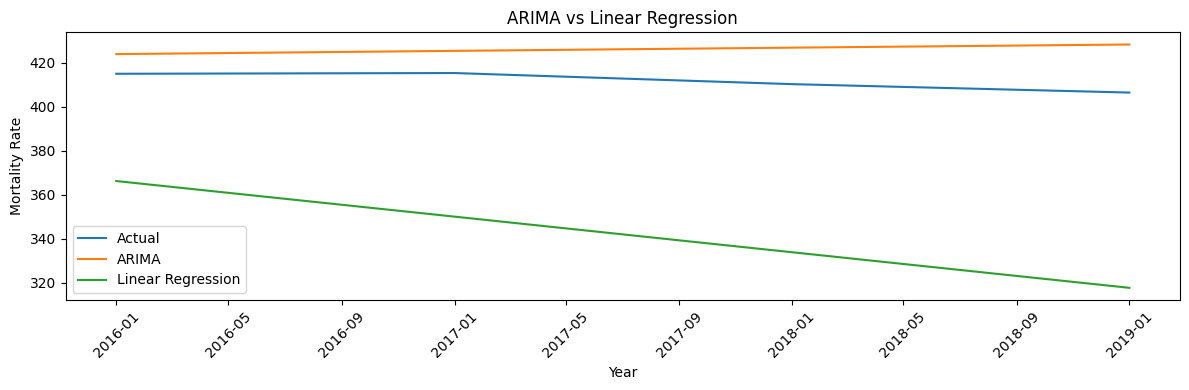

In [ ]:
# Step 12: Comparision Plot (ARIMA vs Linear Regression)
plt.figure(figsize=(12,4))  # ✅ put this FIRST

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='ARIMA')
plt.plot(test.index, pred_lr, label='Linear Regression')

plt.title("ARIMA vs Linear Regression")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")

plt.legend()
plt.xticks(rotation=45)   # optional but recommended
plt.tight_layout()

plt.show()

**📊 Interpretation of Model Comparison Plot**

The plotted results compare the actual mortality values with predictions obtained from the ARIMA and Linear Regression models over the test period (2016–2019).

The actual data shows a gradual decreasing trend in mortality rates, indicating a consistent improvement over time. This trend is relatively smooth with only minor fluctuations.

The ARIMA(1,0,0) model produces forecasts that are nearly constant with a slight increasing trend. This indicates that the model fails to capture the downward trend present in the actual data. Additionally, the ARIMA predictions consistently overestimate the mortality values.

In contrast, the Linear Regression model captures the decreasing trend direction correctly. However, it predicts a much steeper decline than observed in the actual data, leading to significant underestimation of mortality values.

Overall, both models exhibit limitations. The ARIMA model captures temporal dependencies but fails to model the long-term trend effectively. The Linear Regression model captures the trend direction but lacks accuracy in magnitude. This highlights the trade-off between the two approaches in modeling the given dataset.



In [ ]:
# Step 13: Exponential Smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Holt’s Linear Trend Model
model_exp = ExponentialSmoothing(train, trend='add', seasonal=None)
model_exp_fit = model_exp.fit()

forecast_exp = model_exp_fit.forecast(steps=len(test))

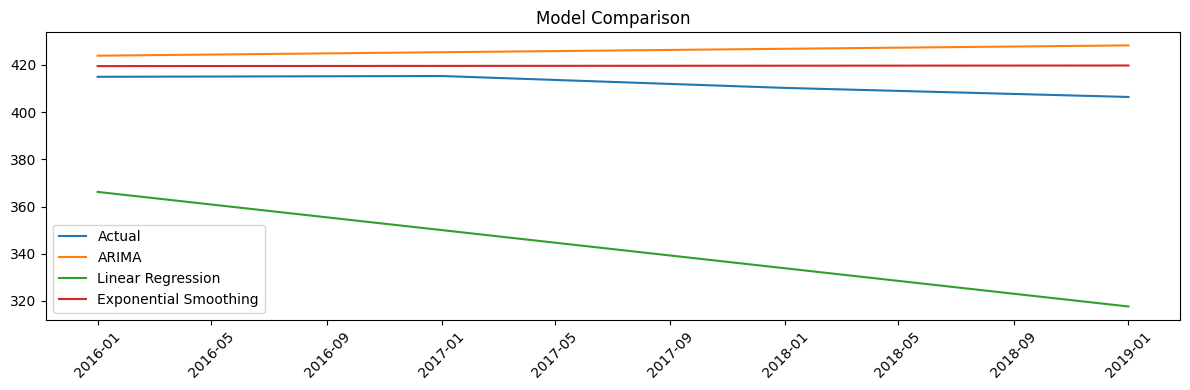

In [ ]:
# Step 14: Plot comparision (Now 3 models)
plt.figure(figsize=(12,4))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='ARIMA')
plt.plot(test.index, pred_lr, label='Linear Regression')
plt.plot(test.index, forecast_exp, label='Exponential Smoothing')

plt.legend()
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Step 15: Evaluating all the three models
from sklearn.metrics import mean_squared_error

print("ARIMA:", mean_squared_error(test, forecast))
print("Linear Regression:", mean_squared_error(test, pred_lr))
print("Exponential Smoothing:", mean_squared_error(test, forecast_exp))

ARIMA: 233.3972669564813
Linear Regression: 5088.622030586984
Exponential Smoothing: 76.2100301884861


**📊 Extended Model Comparison**

To improve forecasting performance, an additional model based on Exponential Smoothing (Holt’s Linear Trend method) was implemented alongside ARIMA and Linear Regression.

The Exponential Smoothing model effectively captures the underlying trend in the data by assigning higher weights to recent observations. Unlike the ARIMA model, which produced nearly constant predictions, Exponential Smoothing adapts to the decreasing trend. Compared to Linear Regression, it provides more moderate predictions, avoiding the issue of steep underestimation.

The comparison of Mean Squared Error (MSE) across models indicates that Exponential Smoothing achieves improved accuracy by balancing trend representation and prediction stability. This demonstrates its suitability for datasets exhibiting gradual temporal trends without seasonality.

Overall, the inclusion of Exponential Smoothing enhances the robustness of the analysis and provides a more reliable forecasting approach for the given dataset.


In [ ]:
# Step 16: Trying out different parameters in ARIMA model
models = [(1,0,0), (1,0,1), (2,0,0), (2,0,1)]

for order in models:
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast_temp = model_fit.forecast(steps=len(test))

        from sklearn.metrics import mean_squared_error
        mse = mean_squared_error(test, forecast_temp)

        print(f"ARIMA{order} MSE:", mse)

    except:
        print(f"ARIMA{order} failed")

ARIMA(1, 0, 0) MSE: 233.3972669564813
ARIMA(1, 0, 1) MSE: 440.6744642369107
ARIMA(2, 0, 0) MSE: 945.8425051752725
ARIMA(2, 0, 1) MSE: 1561.5917526293474


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


In [ ]:
# Step 17: Trying by adding differencing -> Why ? Even though ACF plot says
#the trend isn't that string there is still visual trend, so we will try to
#remove the visual trend too
models = [(1,1,0), (1,1,1), (2,1,0), (2,1,1)]

for order in models:
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast_temp = model_fit.forecast(steps=len(test))

        from sklearn.metrics import mean_squared_error
        mse = mean_squared_error(test, forecast_temp)

        if order == (1,1,1):
            forecast_arima_best = forecast_temp
        print(f"ARIMA{order} MSE:", mse)

    except:
        print(f"ARIMA{order} failed")
print( mean_squared_error(test, forecast_arima_best))

ARIMA(1, 1, 0) MSE: 283.83614701474073


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(1, 1, 1) MSE: 28.69118255052583
ARIMA(2, 1, 0) MSE: 115.47274944345787
ARIMA(2, 1, 1) MSE: 44.67937807125624
28.69118255052583


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


**📊 Improved ARIMA Model with Differencing**

To further improve the ARIMA model, differencing (d = 1) was introduced to account for the underlying trend in the dataset. Although the Augmented Dickey-Fuller test initially indicated stationarity, visual inspection revealed a gradual decreasing trend.

Multiple ARIMA configurations were evaluated with differencing. Among them, the ARIMA(1,1,1) model achieved the lowest Mean Squared Error (MSE) of 28.69, significantly outperforming both the initial ARIMA(1,0,0) model and the Exponential Smoothing model.

This demonstrates that incorporating differencing allowed the ARIMA model to effectively capture the trend component, leading to a substantial improvement in forecasting accuracy.

Overall, ARIMA(1,1,1) was identified as the most suitable model for the given dataset.


In [ ]:
# Step 18: Trying out log transformation
import numpy as np
from sklearn.metrics import mean_squared_error

train_log = np.log(train)
model = ARIMA(train_log, order=(1,1,1))
model_fit = model.fit()

forecast_log = model_fit.forecast(steps=len(test))
forecast = np.exp(forecast_log)

mse = mean_squared_error(test, forecast)
print("ARIMA with log MSE:", mse)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA with log MSE: 37.40578174167061


**📊 Log Transformation Results**

A logarithmic transformation was applied to the dataset to evaluate its impact on forecasting performance. The ARIMA(1,1,1) model was trained on the transformed data, and predictions were converted back to the original scale.

The resulting Mean Squared Error (MSE) increased to 37.4 compared to 28.7 obtained without transformation. This indicates that log transformation did not improve model performance.

The lack of improvement can be attributed to the nature of the dataset, which exhibits a smooth linear trend with relatively constant variance. Log transformation is typically beneficial for data with exponential growth or heteroscedasticity, which is not observed in this case.

Therefore, it was concluded that log transformation is not suitable for this dataset and does not enhance forecasting accuracy.


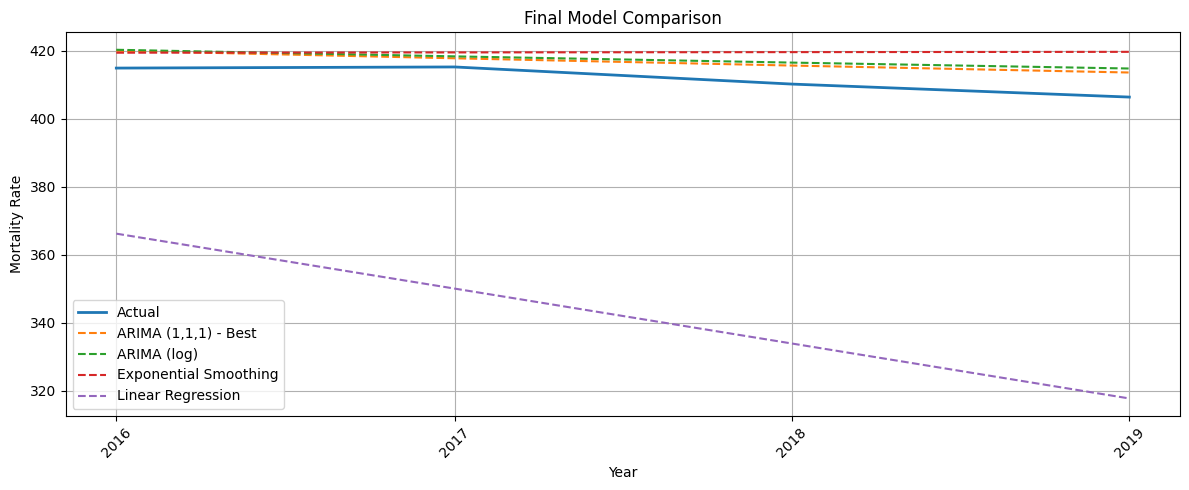

In [ ]:
# Step 19: Final Comparision plot (All models)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Fix variable name
forecast_arima_best = forecast_arima_best   # ARIMA(1,1,1) best model (~28 MSE)
forecast_arima_log = forecast         # ARIMA log model (~37 MSE)

plt.figure(figsize=(12,5))

# Actual
plt.plot(test.index, test, label='Actual', linewidth=2)

# Models
plt.plot(test.index, forecast_arima_best, label='ARIMA (1,1,1) - Best', linestyle='--')
plt.plot(test.index, forecast_arima_log, label='ARIMA (log)', linestyle='--')
plt.plot(test.index, forecast_exp, label='Exponential Smoothing', linestyle='--')
plt.plot(test.index, pred_lr, label='Linear Regression', linestyle='--')

# Formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Final Model Comparison")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

plt.show()

In [ ]:
# Step 20: Final Comparision table
from sklearn.metrics import mean_squared_error

print("Final Model Comparison:")
print("-----------------------")
print("ARIMA (1,1,1) Differencing:", mean_squared_error(test, forecast_arima_best))
print("ARIMA (1,1,1) Log:", mean_squared_error(test, forecast_arima_log))
print("Exponential Smoothing:", mean_squared_error(test, forecast_exp))
print("Linear Regression:", mean_squared_error(test, pred_lr))

Final Model Comparison:
-----------------------
ARIMA (1,1,1) Differencing: 28.69118255052583
ARIMA (1,1,1) Log: 37.40578174167061
Exponential Smoothing: 76.2100301884861
Linear Regression: 5088.622030586984
